# Core ML Pipeline: Non-Linear Regressors

This notebook tests more advanced, non-linear models: Random Forest, Histogram Gradient Boosting, and a Multi-Layer Perceptron (MLP) neural network. These models can map complex decision boundaries without needing manual feature engineering. We use a standardized evaluation process for each to ensure a fair comparison.

In [1]:
import numpy as np
import pandas as pd
import utils
import pickle
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

with open('data/dataset_clean.pkl', 'rb') as file:
    X_train, X_val, X_test, y_train, y_val, y_test = pickle.load(file)['retval']

feature_names = X_train.columns.tolist()

# Create a tuning subset to save time
X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=100000, random_state=42)

# Combine train and val data for final testing across all models
X_train_combined = np.vstack((X_train, X_val))
y_train_combined = np.concatenate((y_train, y_val))

## 1. Random Forest Regressor
### 1.1 Initialization and Optimization

Random Forests reduce variance by averaging many decision trees, making them excellent at handling complex interactions. They also do not require extensive feature scaling. We use a parameter grid search to optimize key structural hyperparameters, like tree depth and forest size, to strike the right balance between variance and bias.

----- Running GridSearchCV -----
Fitting 3 folds for each of 80 candidates, totalling 240 fits


/Users/manthanp/astroML/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Total Runtime: 9.4195 minutes

BEST PARAMETERS:  {'max_depth': 15, 'max_features': 2, 'n_estimators': 300}
BEST CV RMSE:    0.0230538804582349


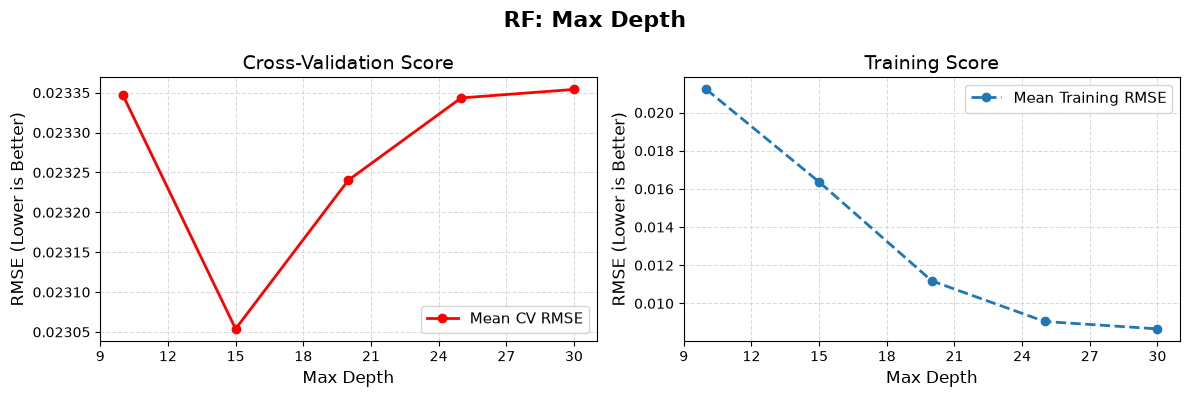

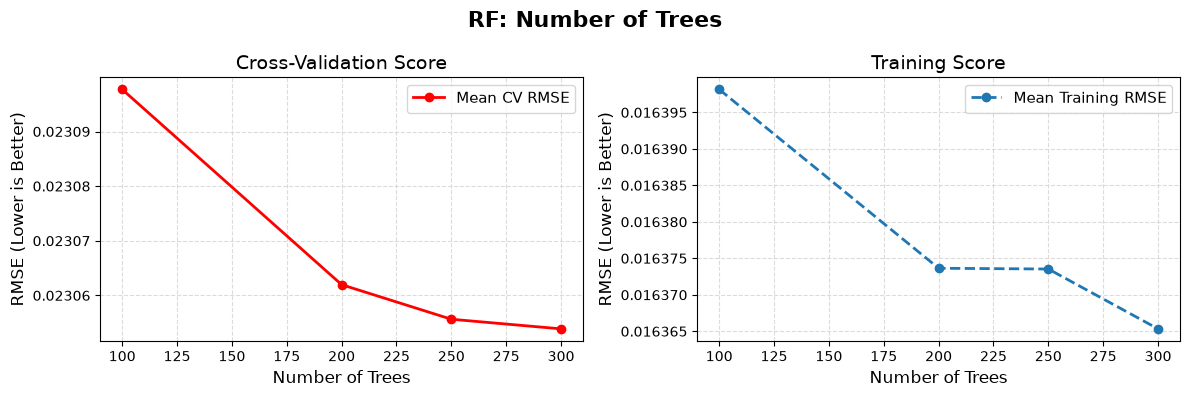

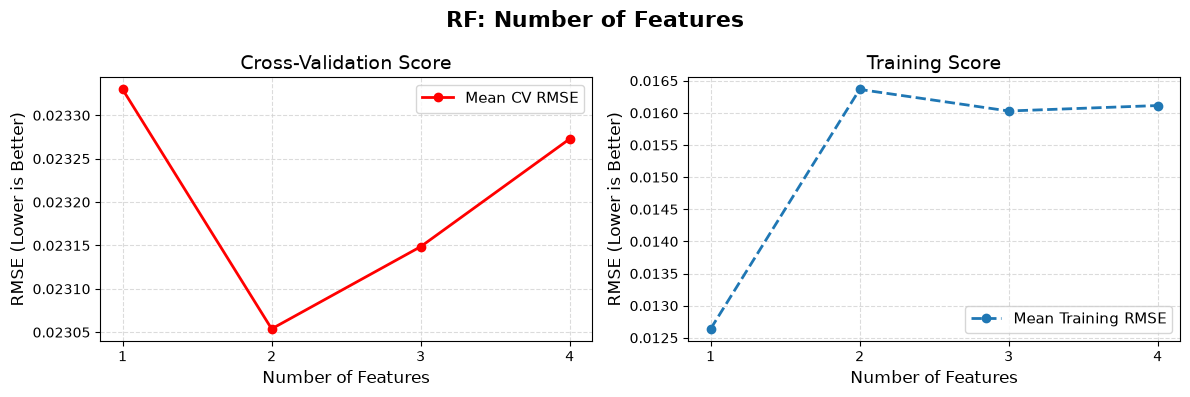

In [2]:
# Initialize the base RF model
rf_base = RandomForestRegressor(max_features='sqrt', random_state=42)

# Define the hyperparameter search space
rf_param_grid = {
    'max_depth': [10, 15, 20, 25, 30], 
    'n_estimators': [100, 200, 250, 300], 
    'max_features': [1, 2, 3, 4]
}

# Run the search using custom function
rf_search, best_params_rf, best_score_rf = utils.optimize_hyper_params(rf_base, X_tune, y_tune, rf_param_grid, 'grid')

# Print the hyperparameter metrics
print("\nBEST PARAMETERS: ", best_params_rf)
print(f"BEST CV RMSE:    {-best_score_rf:.16f}")

# Plot RMSE vs. hyperparameters
utils.plot_side_by_side_diagnostics(rf_search, 'max_depth', 'RF: Max Depth', 'Max Depth')
utils.plot_side_by_side_diagnostics(rf_search, 'n_estimators', 'RF: Number of Trees', 'Number of Trees')
utils.plot_side_by_side_diagnostics(rf_search, 'max_features', 'RF: Number of Features', 'Number of Features')

### 1.2 Validation Set Evaluation

Once the optimal structure is identified, we train the final model on the full training dataset and check its performance on the validation set. This confirms that the model generalizes well rather than memorizing the training samples.

In [3]:
# Initialize and fit the final RF model
rf_final = RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

# Make predictions on the validation set
z_pred_val_rf = rf_final.predict(X_val)

# Print metrics
print( "-" * 4, f"Validation Dataset Metrics", "-" * 4)
utils.metrics(z_pred_val_rf, y_val)

---- Validation Dataset Metrics ----
Outlier Fraction: 0.0247620201286050
Bias:             0.0004832012320641
NMAD:             0.0162753571232854


### 1.3 Test Set Evaluation

We retrain the model on the merged training and validation datasets to maximize the learning samples, then predict redshifts for the test set to get our official benchmark metrics.

In [4]:
# Re-fit the model on the new training set and make predictions on test set
print("=" * 36)
print("FINAL TEST SET EVALUATION")
print(f"Using Hyperparameters: \n{best_params_rf}")
print("=" * 36 + "\n")

rf_final.fit(np.array(X_train_combined), np.array(y_train_combined)) 
z_pred_test_rf = rf_final.predict(np.array(X_test))

# Print metrics
print("-" * 7, f"Test Dataset Metrics", "-" * 7)
utils.metrics(z_pred_test_rf, y_test)

FINAL TEST SET EVALUATION
Using Hyperparameters: 
{'max_depth': 15, 'max_features': 2, 'n_estimators': 300}

------- Test Dataset Metrics -------
Outlier Fraction: 0.0234595816845676
Bias:             0.0004393471826929
NMAD:             0.0160631057703104


### 1.4 Feature Importance Analysis

A primary advantage of Random Forests is their ability to rank feature importance based on variance reduction (impurity). Here we visualize which color indices contribute the most to the model's accuracy, revealing which photometric band differences matter most.

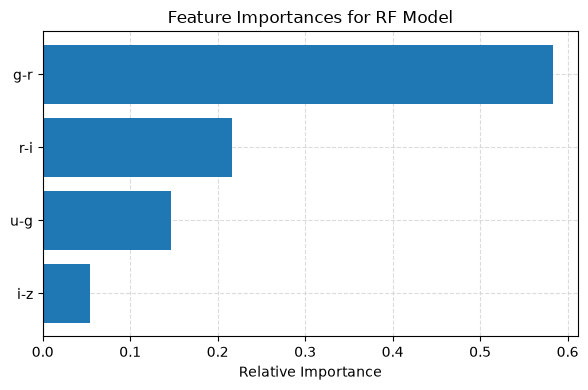

In [5]:
# Get importances of each feature
importances = rf_final.feature_importances_
order = np.argsort(importances)[::-1]

# Plot importance for each feature
plt.figure(figsize=(6, 4))
plt.barh(np.array(feature_names)[order][::-1], importances[order][::-1])
plt.xlabel('Relative Importance')
plt.title("Feature Importances for RF Model")
plt.tight_layout()
plt.gca().set_axisbelow(True)
plt.grid(True, linestyle='--', color='lightgray', alpha=0.8)
plt.show()

## 2. Histogram Gradient Boosting
### 2.1 Initialization and Optimization

Gradient Boosting algorithms build sequential trees where each new tree corrects the residual errors of the previous one. `HistGradientBoostingRegressor` is optimized for massive datasets because it bins continuous features into discrete intervals. We grid search the learning rate, maximum iterations, and tree depth.

----- Running GridSearchCV -----
Fitting 3 folds for each of 120 candidates, totalling 360 fits
Total Runtime: 31.4469 seconds

BEST PARAMETERS:  {'learning_rate': 0.1, 'max_depth': 20, 'max_iter': 200}
BEST CV RMSE:    0.0231858025814328


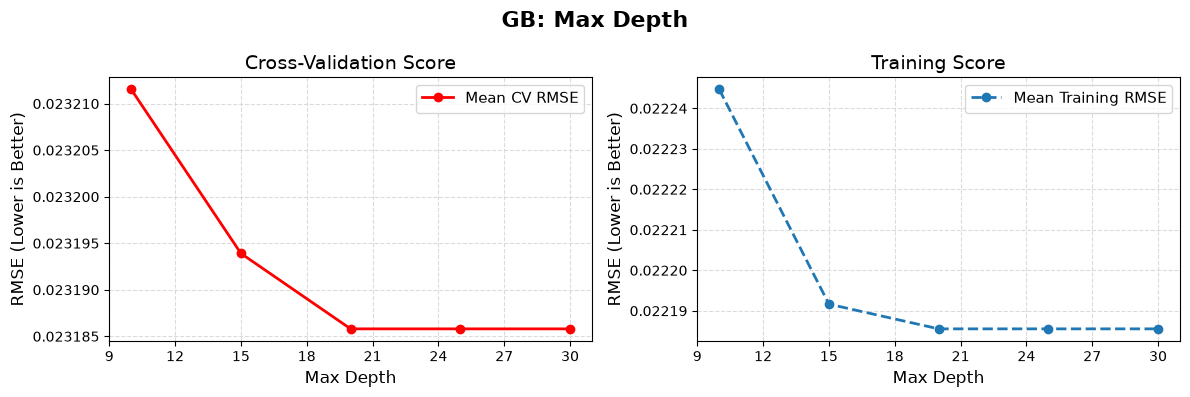

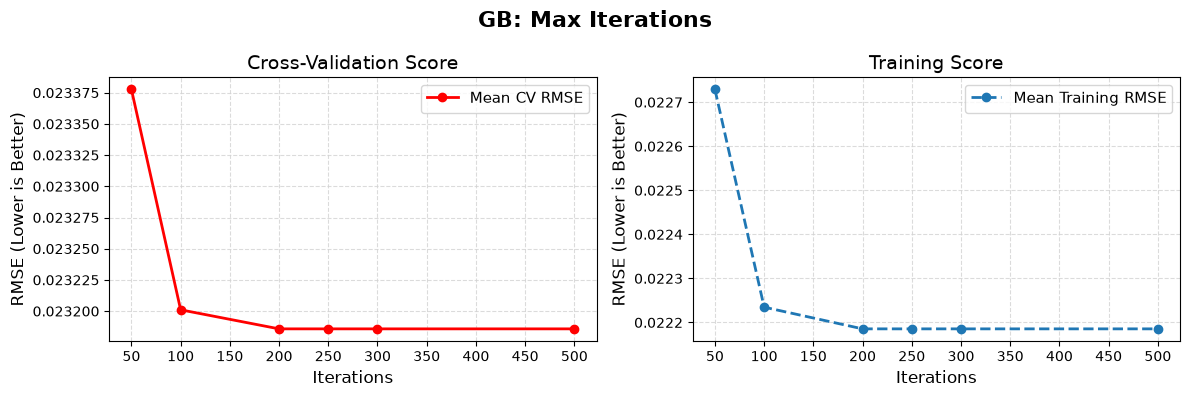

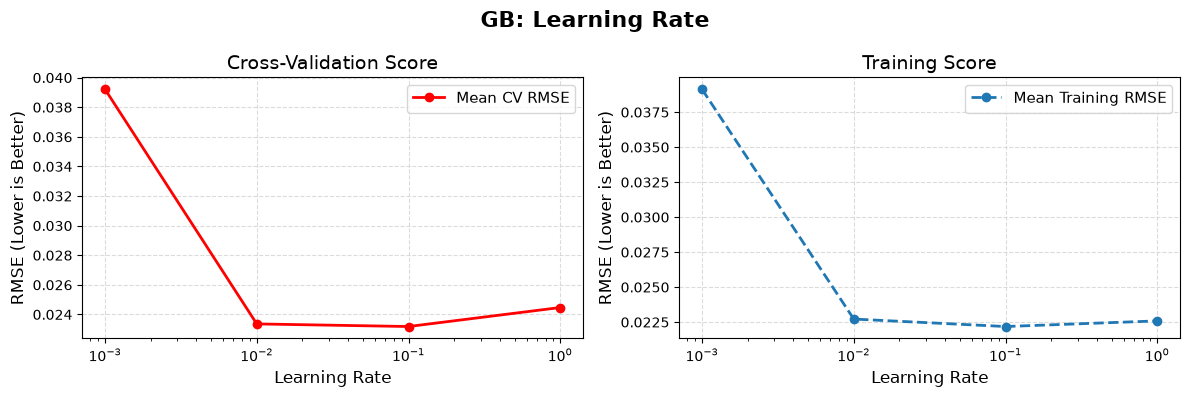

In [6]:
# Initialize the base GB model
gb_base = HistGradientBoostingRegressor(random_state=42)

# Define the hyperparameter search space
gb_param_grid = {
    'learning_rate': [1e-3, 1e-2, 1e-1, 1],
    'max_iter': [50, 100, 200, 250, 300, 500],
    'max_depth': [10, 15, 20, 25, 30]
}

# Run the search using custom function
gb_search, best_params_gb, best_score_gb = utils.optimize_hyper_params(gb_base, X_tune, y_tune, gb_param_grid, 'grid')

# Print the hyperparameter metrics
print("\nBEST PARAMETERS: ", best_params_gb)
print(f"BEST CV RMSE:    {-best_score_gb:.16f}")

# Plot RMSE vs. hyperparameters
utils.plot_side_by_side_diagnostics(search=gb_search, param_name='max_depth', suptitle='GB: Max Depth', xlabel_text='Max Depth')
utils.plot_side_by_side_diagnostics(search=gb_search, param_name='max_iter', suptitle='GB: Max Iterations', xlabel_text='Iterations')
utils.plot_side_by_side_diagnostics(search=gb_search, param_name='learning_rate', suptitle='GB: Learning Rate', xlabel_text='Learning Rate', log=True)

### 2.2 Validation Set Evaluation

We fit the optimized Histogram Gradient Boosting model on the training set and check the validation metrics to ensure our selected learning rate prevented overfitting.

In [7]:
# Initialize and fit the final GB model
gb_final = HistGradientBoostingRegressor(**best_params_gb, random_state=42)
gb_final.fit(X_train, y_train)

# Make predictions on the validations set
z_pred_val_gb = gb_final.predict(X_val)

# Print metrics
print( "-" * 4, f"Validation Dataset Metrics", "-" * 4)
utils.metrics(z_pred_val_gb, y_val)

---- Validation Dataset Metrics ----
Outlier Fraction: 0.0248730605776122
Bias:             0.0004837855293754
NMAD:             0.0164023106314274


### 2.3 Test Set Evaluation

We fit the final model to the combined dataset and run predictions on the test set for our definitive performance metrics.

In [8]:
# Re-fit the model on the new training set and make predictions on test set
print("=" * 36)
print("FINAL TEST SET EVALUATION")
print(f"Using Hyperparameters: \n{best_params_gb}")
print("=" * 36 + "\n")

gb_final.fit(np.array(X_train_combined), np.array(y_train_combined)) 
z_pred_test_gb = gb_final.predict(np.array(X_test))

# Print metrics
print("-" * 7, f"Test Dataset Metrics", "-" * 7)
utils.metrics(z_pred_test_gb, y_test)

FINAL TEST SET EVALUATION
Using Hyperparameters: 
{'learning_rate': 0.1, 'max_depth': 20, 'max_iter': 200}

------- Test Dataset Metrics -------
Outlier Fraction: 0.0238128886376484
Bias:             0.0004433321734412
NMAD:             0.0162589102759891


## 3. Multi-Layer Perceptron (MLP)
### 3.1 Initialization and Optimization

Neural networks act as universal approximators for highly complex functions but are extremely sensitive to feature scales. Therefore, we use a scaling pipeline for both input features ($X$) and target values ($y$). Our grid search optimizes hidden layer sizes, learning rate, activation function, and L2 regularization (alpha).

----- Running GridSearchCV -----
Fitting 3 folds for each of 128 candidates, totalling 384 fits
Total Runtime: 3.6592 minutes

BEST PARAMETERS:  {'mlp__activation': 'relu', 'mlp__alpha': 1e-06, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.001}
BEST CV RMSE:    0.0228588835646709


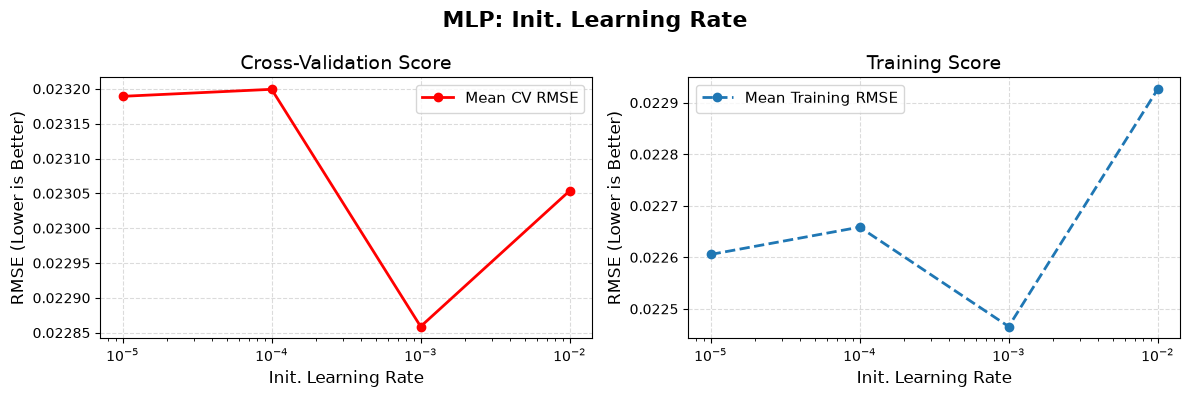

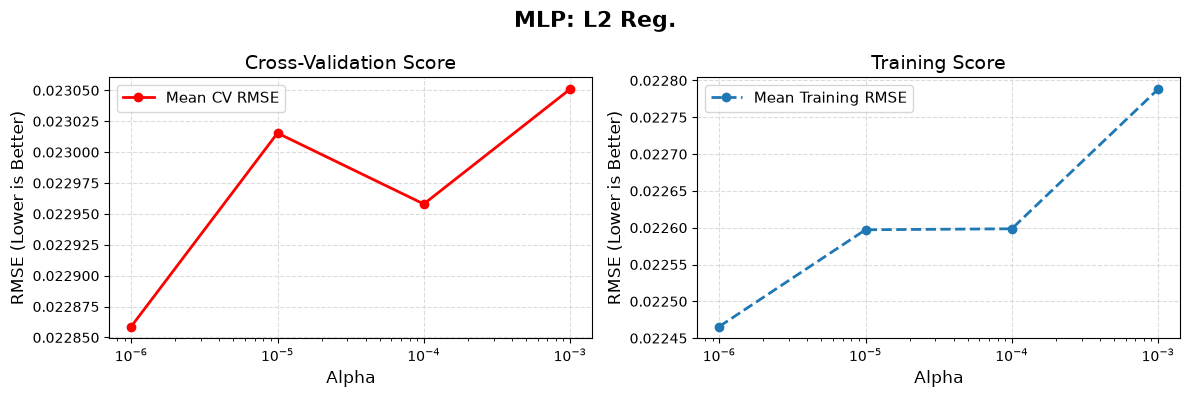

In [9]:
# Scale the target in tuning set
scaler_y_tune = MinMaxScaler()
y_tune_scaled = scaler_y_tune.fit_transform(y_tune.values.reshape(-1, 1)).ravel()

# Build a Pipeline (scaler + model)
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('mlp', MLPRegressor(solver='adam', max_iter=1000, early_stopping=True, n_iter_no_change=10, validation_fraction=0.1, random_state=42))
])

# Define the hyperparameter search space
mlp_param_grid = {
    'mlp__hidden_layer_sizes': [(128, 64), (64, 32), (128, 64, 32), (64, 32, 16)],
    'mlp__learning_rate_init': [1e-5, 1e-4, 1e-3, 1e-2],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [1e-6, 1e-5, 1e-4, 1e-3]
}

# Run the search using custom function
mlp_search, best_params_mlp, best_score_mlp = utils.optimize_hyper_params(mlp_pipeline, X_tune, y_tune, mlp_param_grid, 'grid')

# Print the hyperparameter metrics
print("\nBEST PARAMETERS: ", best_params_mlp)
print(f"BEST CV RMSE:    {-best_score_mlp:.16f}")

# Plot RMSE vs. hyperparameters
utils.plot_side_by_side_diagnostics(search=mlp_search, param_name='mlp__learning_rate_init', suptitle='MLP: Init. Learning Rate', xlabel_text='Init. Learning Rate', log=True)
utils.plot_side_by_side_diagnostics(search=mlp_search, param_name='mlp__alpha', suptitle='MLP: L2 Reg.', xlabel_text='Alpha', log=True)

### 3.2 Validation Set Evaluation

We apply our scalers to the arrays, train the model, and then carefully inverse-transform the scaled predictions back into physical redshift space to compute our standard metrics.

In [10]:
# Initialize the two different scalers
scaler_X = StandardScaler()
scaler_y = MinMaxScaler()

# Scale the features
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)

# Scale the targets
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).ravel()

# Initialize and fit the final MLP model
clean_params = {key.replace('mlp__', ''): value for key, value in best_params_mlp.items()}
mlp_final = MLPRegressor(**clean_params, max_iter=1000, early_stopping=True, n_iter_no_change=10, validation_fraction=0.1, random_state=42)
mlp_final.fit(X_train_scaled, y_train_scaled)

# Make predictions on the validation set
scaled_predictions = mlp_final.predict(X_val_scaled)

# Untransform the predictions
z_pred_val_mlp = scaler_y.inverse_transform(scaled_predictions.reshape(-1, 1)).ravel()

# Print metrics
print( "-" * 4, f"Validation Dataset Metrics", "-" * 4)
utils.metrics(z_pred_val_mlp, y_val)

---- Validation Dataset Metrics ----
Outlier Fraction: 0.0248831551638856
Bias:             0.0001185453365906
NMAD:             0.0161584019660950


### 3.3 Test Set Evaluation

We re-fit the scalers on the combined dataset and train the MLP. This strict process guarantees no data leakage occurs through the statistical scaling parameters during final testing.

In [11]:
# Scale the combined training dataset
X_train_combined_scaled = scaler_X.fit_transform(X_train_combined)
y_train_combined_scaled = scaler_y.fit_transform(y_train_combined.reshape(-1, 1)).ravel()

# Re-fit the model on the new training set and make predictions on test set
print("=" * 36)
print("FINAL TEST SET EVALUATION")
print(f"Using Hyperparameters: \n{best_params_mlp}")
print("=" * 36 + "\n")

mlp_final.fit(X_train_combined_scaled, y_train_combined_scaled) 
X_test_scaled = scaler_X.transform(np.array(X_test))
z_pred_test_mlp_scaled = mlp_final.predict(X_test_scaled)

# Untransform the predictions
z_pred_test_mlp = scaler_y.inverse_transform(z_pred_test_mlp_scaled.reshape(-1, 1)).ravel()

# Print metrics
print("-" * 7, f"Test Dataset Metrics", "-" * 7)
utils.metrics(z_pred_test_mlp, y_test)

FINAL TEST SET EVALUATION
Using Hyperparameters: 
{'mlp__activation': 'relu', 'mlp__alpha': 1e-06, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.001}

------- Test Dataset Metrics -------
Outlier Fraction: 0.0231870306064766
Bias:             0.0015505925985053
NMAD:             0.0160387530922890


## 4. Comparative Error Analysis

Aggregate metrics can obscure regions where models inherently struggle. We will analyze the errors binned by true redshift and by i-band magnitude to see how models handle distant or faint galaxies.

=====  Binned by Redshift  =====
---- Random Forest ----
bin         N         bias                     nmad                     outlier_frac             
0.02-0.05   12131     0.0213534238519155       0.0145615968418880       0.0483059929107246       
0.05-0.08   20352     0.0079713074901367       0.0128748449872943       0.0099744496855346       
0.08-0.10   14466     0.0003454451203817       0.0148397923097182       0.0064288676897553       
0.10-0.15   30557     -0.0064484240927274      0.0161761325724090       0.0238243283044802       
0.15-0.20   15183     -0.0074339167302792      0.0145363522511189       0.0366857669762234       
0.20-0.25   4811      -0.0090818964695387      0.0150871494508503       0.0357514030347121       
0.25-0.30   1285      -0.0128876724646988      0.0146940708283316       0.0560311284046693       




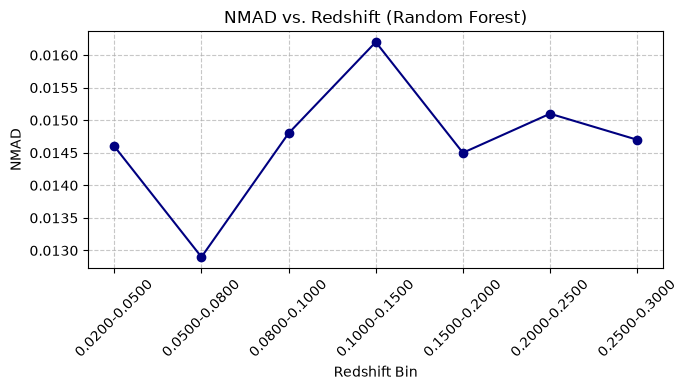

---- Gradient Boosting ----
bin         N         bias                     nmad                     outlier_frac             
0.02-0.05   12131     0.0214013120085728       0.0145418004919510       0.0482235594757234       
0.05-0.08   20352     0.0078434234492083       0.0130319999505531       0.0107606132075472       
0.08-0.10   14466     0.0002777363553347       0.0150513676509236       0.0071201437854279       
0.10-0.15   30557     -0.0064946552504974      0.0164286870255267       0.0239225054815591       
0.15-0.20   15183     -0.0070409513394507      0.0145185519240537       0.0355002305209774       
0.20-0.25   4811      -0.0092635145273229      0.0147990347934913       0.0357514030347121       
0.25-0.30   1285      -0.0125458686525361      0.0161134433886129       0.0568093385214008       




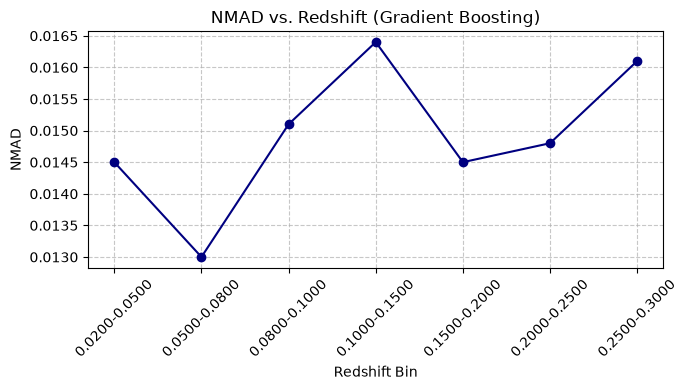

---- MLP ----
bin         N         bias                     nmad                     outlier_frac             
0.02-0.05   12131     0.0201004594564438       0.0136322528123856       0.0476465254307147       
0.05-0.08   20352     0.0068251886405051       0.0133933033794165       0.0112519654088050       
0.08-0.10   14466     -0.0002952447975986      0.0154573628678918       0.0063597400801880       
0.10-0.15   30557     -0.0065180929377675      0.0160104371607304       0.0256569689432863       
0.15-0.20   15183     -0.0073644486255944      0.0143302446231246       0.0340512415201212       
0.20-0.25   4811      -0.0075353379361331      0.0160416048020124       0.0334649760964456       
0.25-0.30   1285      -0.0093613527715206      0.0153637006878853       0.0521400778210117       




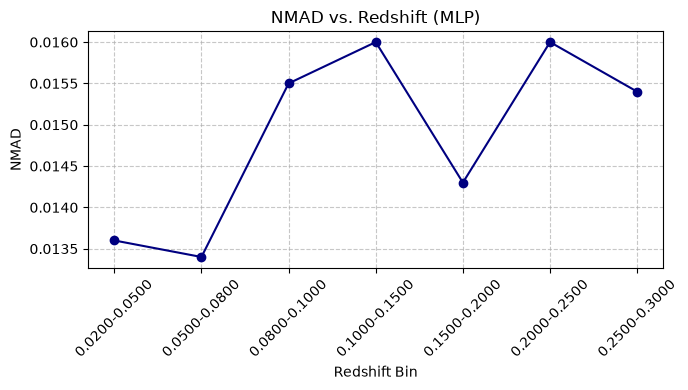

In [12]:
# Create bins for error analysis by redshift for both models
z_bins = [0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]

# Load i-band magnitudes
with open('data/full_dataset_clean.pkl', 'rb') as file:
    df_full = pickle.load(file)
i_mag_val = df_full.loc[X_val.index, 'modelMag_i']
mag_bins = np.percentile(i_mag_val, [0, 20, 40, 60, 80, 100])

print("=" * 5, " Binned by Redshift ", "=" * 5)
# Random Forest
utils.binned_metrics(z_pred_val_rf, y_val, y_val, z_bins, label="Random Forest")
utils.plot_binned_metric(y_val, z_bins, 'Redshift Bin', 'NMAD', 'NMAD vs. Redshift (Random Forest)', 'nmad', z_pred_val_rf, y_val)

# Gradient Boosting
utils.binned_metrics(z_pred_val_gb, y_val, y_val, z_bins, label="Gradient Boosting")
utils.plot_binned_metric(y_val, z_bins, 'Redshift Bin', 'NMAD', 'NMAD vs. Redshift (Gradient Boosting)', 'nmad', z_pred_val_gb, y_val)

# Multi-Layer Perceptron
utils.binned_metrics(z_pred_val_mlp, y_val, y_val, z_bins, label="MLP")
utils.plot_binned_metric(y_val, z_bins, 'Redshift Bin', 'NMAD', 'NMAD vs. Redshift (MLP)', 'nmad', z_pred_val_mlp, y_val)

=====  Binned by i-band Magnitude  =====
---- Random Forest ----
bin         N         bias                     nmad                     outlier_frac             
11.51-16.15   19813     0.0113493094787510       0.0152208052696004       0.0230656639580074       
16.15-16.66   19812     0.0022006083273725       0.0140264730584994       0.0140318998586715       
16.66-16.96   19813     -0.0013212774346574      0.0147813786373606       0.0175137535961238       
16.96-17.20   19812     -0.0035977741693149      0.0160248863588097       0.0247324853624066       
17.20-22.33   19812     -0.0062160180295809      0.0190364915168093       0.0444679991924086       




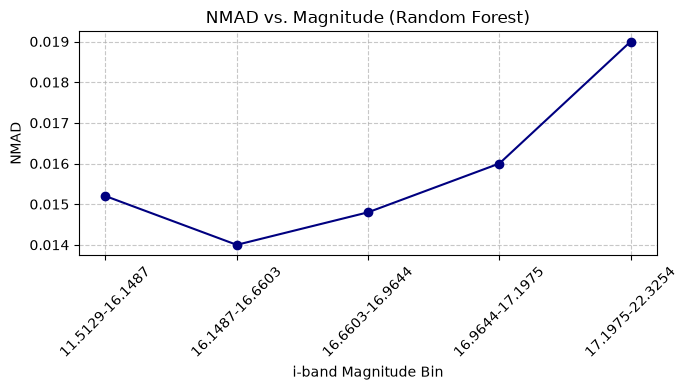

---- Gradient Boosting ----
bin         N         bias                     nmad                     outlier_frac             
11.51-16.15   19813     0.0111888570487334       0.0153605572013406       0.0234189673446727       
16.15-16.66   19812     0.0021005903752414       0.0140786763111535       0.0142337976983646       
16.66-16.96   19813     -0.0013270694327929      0.0149407153089665       0.0182708322818352       
16.96-17.20   19812     -0.0034865432799122      0.0161662042437058       0.0243286896830204       
17.20-22.33   19812     -0.0060572891930324      0.0193570078931218       0.0441146779729457       




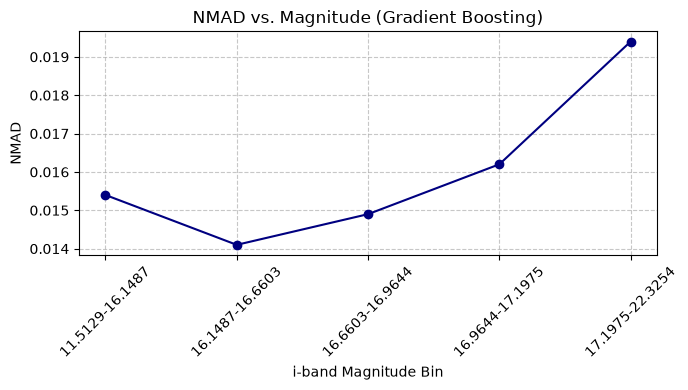

---- MLP ----
bin         N         bias                     nmad                     outlier_frac             
11.51-16.15   19813     0.0099714994430542       0.0149049675092101       0.0227628324837228       
16.15-16.66   19812     0.0016361735761166       0.0140477977693081       0.0147385422975974       
16.66-16.96   19813     -0.0014995462261140      0.0149154532700777       0.0185736637561197       
16.96-17.20   19812     -0.0035638893023133      0.0159358121454716       0.0251362810417929       
17.20-22.33   19812     -0.0059521570801735      0.0188344754278660       0.0432061376943267       




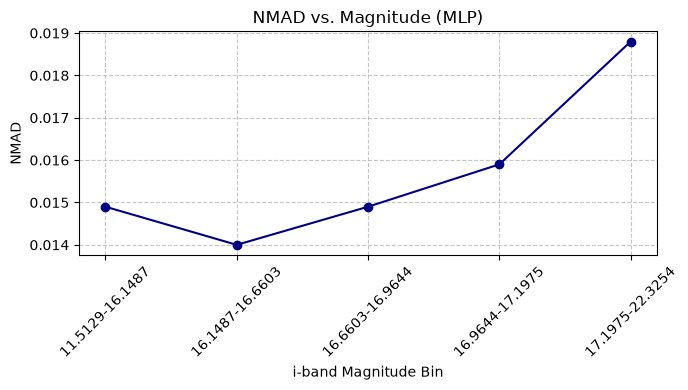

In [13]:
print("=" * 5, " Binned by i-band Magnitude ", "=" * 5)
# Random Forest
utils.binned_metrics(z_pred_val_rf, y_val, i_mag_val, mag_bins, label="Random Forest")
utils.plot_binned_metric(i_mag_val, mag_bins, 'i-band Magnitude Bin', 'NMAD', 'NMAD vs. Magnitude (Random Forest)', 'nmad', z_pred_val_rf, y_val)

#Gradient Boosting
utils.binned_metrics(z_pred_val_gb, y_val, i_mag_val, mag_bins, label="Gradient Boosting")
utils.plot_binned_metric(i_mag_val, mag_bins, 'i-band Magnitude Bin', 'NMAD', 'NMAD vs. Magnitude (Gradient Boosting)',  'nmad', z_pred_val_gb, y_val)

# Multi-Layer Perceptron
utils.binned_metrics(z_pred_val_mlp, y_val, i_mag_val, mag_bins, label="MLP")
utils.plot_binned_metric(i_mag_val, mag_bins, 'i-band Magnitude Bin', 'NMAD', 'NMAD vs. Magnitude (MLP)', 'nmad', z_pred_val_mlp, y_val)

### 4.1 Degenerate Region Assessment

We isolate the validation galaxies falling inside the severely degenerate boundary (`g-r ∈ [0.4, 0.75]`, `r-i ∈ [0.15, 0.35]`) mapped out earlier in `01_data_exploration.ipynb`. Comparing performance in this region against the rest of the sample quantifies how predictive accuracy degrades when fundamental photometric information overlaps.

In [14]:
# Define the degenerate region
degenerate_mask = (
    (X_val['g-r'] > 0.4) & (X_val['g-r'] < 0.75) &
    (X_val['r-i'] > 0.15) & (X_val['r-i'] < 0.35)
)

# Use the mask to compare model performance in the degenerate region vs. the rest of the sample
for name, preds_val in [('Random Forest', z_pred_val_rf), ('Gradient Boosting', z_pred_val_gb), ('MLP', z_pred_val_mlp)]:
    zt_deg, zp_deg = y_val[degenerate_mask], preds_val[degenerate_mask]
    zt_rest, zp_rest = y_val[~degenerate_mask], preds_val[~degenerate_mask]

    print( "-" * 4, f"{name} Degenerate Region Check", "-" * 4)
    
    print(f"Degenerate region (N={degenerate_mask.sum()}):")
    print(f"  Outlier Fraction: {utils.outlier_fraction(zp_deg, zt_deg):.16f}")
    print(f"  Bias:             {utils.bias(zp_deg, zt_deg):.16f}")
    print(f"  NMAD:             {utils.nmad(zp_deg, zt_deg):.16f}")
    
    print(f"Rest of sample (N={(~degenerate_mask).sum()}):")
    print(f"  Outlier Fraction: {utils.outlier_fraction(zp_rest, zt_rest):.16f}")
    print(f"  Bias:             {utils.bias(zp_rest, zt_rest):.16f}")
    print(f"  NMAD:             {utils.nmad(zp_rest, zt_rest):.16f}\n")

---- Random Forest Degenerate Region Check ----
Degenerate region (N=12000):
  Outlier Fraction: 0.0380833333333333
  Bias:             0.0005166524639295
  NMAD:             0.0202506161593711
Rest of sample (N=87063):
  Outlier Fraction: 0.0229259272021410
  Bias:             0.0004785906077762
  NMAD:             0.0157199871062516

---- Gradient Boosting Degenerate Region Check ----
Degenerate region (N=12000):
  Outlier Fraction: 0.0365833333333333
  Bias:             0.0004831382578345
  NMAD:             0.0207009459043572
Rest of sample (N=87063):
  Outlier Fraction: 0.0232590193308294
  Bias:             0.0004838747436053
  NMAD:             0.0158381349173999

---- MLP Degenerate Region Check ----
Degenerate region (N=12000):
  Outlier Fraction: 0.0379166666666667
  Bias:             0.0008760434575379
  NMAD:             0.0201151147484779
Rest of sample (N=87063):
  Outlier Fraction: 0.0230867302987492
  Bias:             0.0000141384271046
  NMAD:             0.0155643159